IMPORT LIBRARY

In [1]:
import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

print("OpenCV Version:", cv2.__version__)
print("NumPy Version:", np.__version__)

OpenCV Version: 5.0.0
NumPy Version: 2.3.1


In [2]:
input_folder = "../Preprocessed_Dataset"
reference_folder = "../PCB_DATASET/PCB_USED"
output_folder = "../Calibrated_Dataset"


os.makedirs(output_folder, exist_ok=True)


print("Input:", input_folder)
print("Reference:", reference_folder)
print("Output:", output_folder)

classes = [
    folder for folder in os.listdir(input_folder)
    if os.path.isdir(os.path.join(input_folder, folder))
]

print(classes)

Input: ../Preprocessed_Dataset
Reference: ../PCB_DATASET/PCB_USED
Output: ../Calibrated_Dataset
['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']


IMPORT FILES

In [3]:
images = []

for cls in classes:

    class_path = os.path.join(input_folder, cls)

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    for file in files:
        images.append(
            (
                cls,
                os.path.join(class_path, file)
            )
        )

print("Total Images:", len(images))
print(images[0])

Total Images: 693
('Missing_hole', '../Preprocessed_Dataset\\Missing_hole\\01_missing_hole_01.jpg')


GrayScale Conversion for SIFT

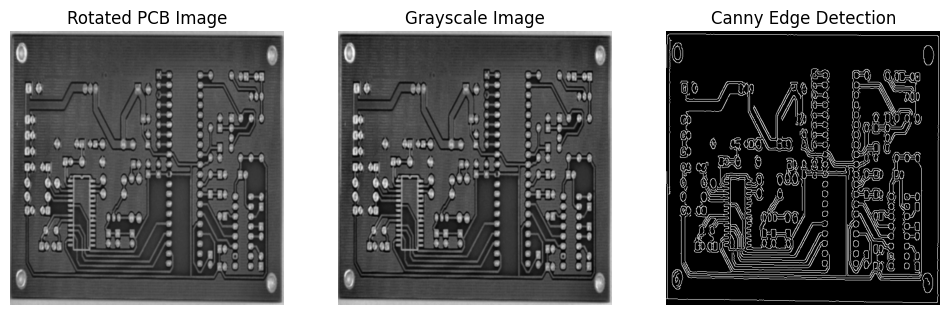

Done Processing


In [4]:
for index, (cls, image_path) in enumerate(images):

    image = cv2.imread(image_path)

    if image is None:
        print("Failed:", image_path)
        continue

    # Convert to grayscale
    gray_image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # Apply Gaussian blur
    blurred_image = cv2.GaussianBlur(
        gray_image,
        (5,5),
        0
    )


    # Canny edge detection
    edges = cv2.Canny(
        blurred_image,
        50,
        150
    )


    # Display only first image result
    if index == 0:

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.imshow(
            cv2.cvtColor(
                image,
                cv2.COLOR_BGR2RGB
            )
        )
        plt.title("Rotated PCB Image")
        plt.axis("off")


        plt.subplot(1,3,2)
        plt.imshow(
            gray_image,
            cmap="gray"
        )
        plt.title("Grayscale Image")
        plt.axis("off")


        plt.subplot(1,3,3)
        plt.imshow(
            edges,
            cmap="gray"
        )
        plt.title("Canny Edge Detection")
        plt.axis("off")


        plt.show()

print("Done Processing")

Contour Detection for PCB Boundary

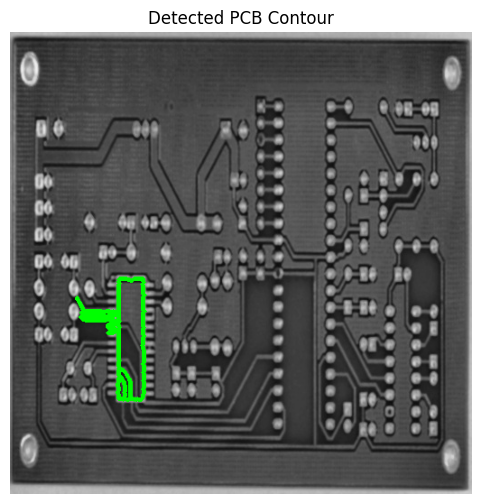

Done Processing


In [5]:
for index, (cls, image_path) in enumerate(images):

    image = cv2.imread(image_path)

    if image is None:
        continue

    # Grayscale
    gray_image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # Blur
    blurred_image = cv2.GaussianBlur(
        gray_image,
        (5,5),
        0
    )

    # Canny
    edges = cv2.Canny(
        blurred_image,
        50,
        150
    )


    # Find contours
    contours, hierarchy = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )


    if len(contours) == 0:
        print("No contour:", image_path)
        continue


    # Select largest contour
    largest_contour = max(
        contours,
        key=cv2.contourArea
    )
    # Draw contour
    contour_image = image.copy()

    cv2.drawContours(
        contour_image,
        [largest_contour],
        -1,
        (0,255,0),
        3
    )


    # Display first result only
    if index == 0:

        plt.figure(figsize=(8,6))

        plt.imshow(
            cv2.cvtColor(
                contour_image,
                cv2.COLOR_BGR2RGB
            )
        )

        plt.title("Detected PCB Contour")
        plt.axis("off")

        plt.show()
print("Done Processing")

Display fields

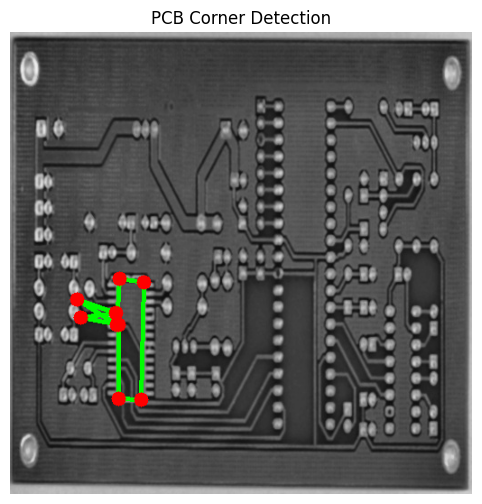

Done Processing


In [6]:
for index, (cls, image_path) in enumerate(images):

    image = cv2.imread(image_path)

    if image is None:
        continue


    # Grayscale
    gray_image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # Blur
    blurred_image = cv2.GaussianBlur(
        gray_image,
        (5,5),
        0
    )


    # Canny
    edges = cv2.Canny(
        blurred_image,
        50,
        150
    )


    # Find contours
    contours, hierarchy = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )


    if len(contours) == 0:
        continue


    # Largest contour
    largest_contour = max(
        contours,
        key=cv2.contourArea
    )


    # Calculate perimeter
    perimeter = cv2.arcLength(
        largest_contour,
        True
    )


    # Approximate contour
    epsilon = 0.02 * perimeter

    approx = cv2.approxPolyDP(
        largest_contour,
        epsilon,
        True
    )

    # Draw result
    corner_image = image.copy()


    cv2.drawContours(
        corner_image,
        [approx],
        -1,
        (0,255,0),
        3
    )


    for point in approx:

        x, y = point[0]

        cv2.circle(
            corner_image,
            (x,y),
            8,
            (0,0,255),
            -1
        )


    # Display first image only
    if index == 0:

        plt.figure(figsize=(8,6))

        plt.imshow(
            cv2.cvtColor(
                corner_image,
                cv2.COLOR_BGR2RGB
            )
        )

        plt.title("PCB Corner Detection")
        plt.axis("off")

        plt.show()

print("Done Processing")

Display References and Rotated Images

In [7]:
for index, (cls, image_path) in enumerate(images):

    image = cv2.imread(image_path)

    if image is None:
        continue


    # Grayscale
    gray_image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # Blur
    blurred_image = cv2.GaussianBlur(
        gray_image,
        (5,5),
        0
    )


    # Canny
    edges = cv2.Canny(
        blurred_image,
        50,
        150
    )


    # Find contours
    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )


    if len(contours) == 0:
        continue


    # Largest contour
    largest_contour = max(
        contours,
        key=cv2.contourArea
    )


    # Approximate contour
    perimeter = cv2.arcLength(
        largest_contour,
        True
    )

    approx = cv2.approxPolyDP(
        largest_contour,
        0.02 * perimeter,
        True
    )


    # Need exactly 4 corners
    if len(approx) != 4:
        print(
            "Skipped:",
            image_path,
            "Corners:",
            len(approx)
        )
        continue


    # Convert points
    points = approx.reshape(4, 2)


    # Calculate sums and differences
    sum_points = points.sum(axis=1)
    diff_points = np.diff(
        points,
        axis=1
    ).reshape(4)


    # Order points
    ordered_points = np.zeros(
        (4,2),
        dtype="float32"
    )


    ordered_points[0] = points[np.argmin(sum_points)]   # Top-left
    ordered_points[2] = points[np.argmax(sum_points)]   # Bottom-right
    ordered_points[1] = points[np.argmin(diff_points)]  # Top-right
    ordered_points[3] = points[np.argmax(diff_points)]  # Bottom-left



    # Display first result only
    if index == 0:

        corner_image = image.copy()

        for i, point in enumerate(ordered_points):

            x, y = point.astype(int)

            cv2.circle(
                corner_image,
                (x,y),
                8,
                (0,0,255),
                -1
            )

            cv2.putText(
                corner_image,
                str(i+1),
                (x+10,y),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (255,0,0),
                2
            )


        plt.figure(figsize=(8,6))

        plt.imshow(
            cv2.cvtColor(
                corner_image,
                cv2.COLOR_BGR2RGB
            )
        )

        plt.title("Ordered PCB Corner Points")
        plt.axis("off")

        plt.show()
print("Done Processing")

Skipped: ../Preprocessed_Dataset\Missing_hole\01_missing_hole_01.jpg Corners: 9
Skipped: ../Preprocessed_Dataset\Missing_hole\01_missing_hole_02.jpg Corners: 9
Skipped: ../Preprocessed_Dataset\Missing_hole\01_missing_hole_03.jpg Corners: 9
Skipped: ../Preprocessed_Dataset\Missing_hole\01_missing_hole_04.jpg Corners: 9
Skipped: ../Preprocessed_Dataset\Missing_hole\01_missing_hole_05.jpg Corners: 9
Skipped: ../Preprocessed_Dataset\Missing_hole\01_missing_hole_06.jpg Corners: 9
Skipped: ../Preprocessed_Dataset\Missing_hole\01_missing_hole_07.jpg Corners: 9
Skipped: ../Preprocessed_Dataset\Missing_hole\01_missing_hole_08.jpg Corners: 10
Skipped: ../Preprocessed_Dataset\Missing_hole\01_missing_hole_09.jpg Corners: 9
Skipped: ../Preprocessed_Dataset\Missing_hole\01_missing_hole_10.jpg Corners: 9
Skipped: ../Preprocessed_Dataset\Missing_hole\01_missing_hole_11.jpg Corners: 9
Skipped: ../Preprocessed_Dataset\Missing_hole\01_missing_hole_12.jpg Corners: 9
Skipped: ../Preprocessed_Dataset\Missin

Perspective Transformation

In [8]:
width = 640
height = 640

destination_points = np.float32([
    [0, 0],
    [width, 0],
    [width, height],
    [0, height]
])


for index, (cls, image_path) in enumerate(images):

    image = cv2.imread(image_path)

    if image is None:
        continue


    # Grayscale
    gray_image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # Blur
    blurred_image = cv2.GaussianBlur(
        gray_image,
        (5,5),
        0
    )


    # Canny
    edges = cv2.Canny(
        blurred_image,
        50,
        150
    )


    # Find contours
    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )


    if len(contours) == 0:
        continue


    # Largest contour
    largest_contour = max(
        contours,
        key=cv2.contourArea
    )


    # Approximate contour
    perimeter = cv2.arcLength(
        largest_contour,
        True
    )

    approx = cv2.approxPolyDP(
        largest_contour,
        0.02 * perimeter,
        True
    )


    # Require 4 corners
    if len(approx) != 4:
        continue


    # Get corner points
    points = approx.reshape(4,2)


    sum_points = points.sum(axis=1)
    diff_points = np.diff(
        points,
        axis=1
    ).reshape(4)


    ordered_points = np.zeros(
        (4,2),
        dtype="float32"
    )


    ordered_points[0] = points[np.argmin(sum_points)]
    ordered_points[2] = points[np.argmax(sum_points)]
    ordered_points[1] = points[np.argmin(diff_points)]
    ordered_points[3] = points[np.argmax(diff_points)]


    # Perspective transformation
    matrix = cv2.getPerspectiveTransform(
        ordered_points,
        destination_points
    )


    aligned_image = cv2.warpPerspective(
        image,
        matrix,
        (width,height)
    )


    # Display first result only
    if index == 0:

        plt.figure(figsize=(12,5))

        plt.subplot(1,2,1)
        plt.imshow(
            cv2.cvtColor(
                image,
                cv2.COLOR_BGR2RGB
            )
        )
        plt.title("Before Alignment")
        plt.axis("off")


        plt.subplot(1,2,2)
        plt.imshow(
            cv2.cvtColor(
                aligned_image,
                cv2.COLOR_BGR2RGB
            )
        )
        plt.title("Aligned PCB")
        plt.axis("off")


        plt.show()
print("Done Processing")

Done Processing


Save Files

In [9]:
count = 0
for cls, image_path in images:

    # Create class output folder

    class_output = os.path.join(
        output_folder,
        cls
    )

    os.makedirs(
        class_output,
        exist_ok=True
    )


    # Save aligned PCB image

    output_path = os.path.join(
        class_output,
        os.path.basename(image_path)
    )


    cv2.imwrite(
        output_path,
        aligned_image
    )
    count += 1

print(count," Images Saved")

693  Images Saved
